# Macosko dataset
- Downloaded from [lab's google drive](https://drive.google.com/drive/folders/16P10yDckZ6Zs2GxPiX4bg7KnH9BthqIx)
- Single nuclei data

In [1]:
# load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# snRNAseq
import anndata as ad
import scanpy as sc


# Load data

In [ ]:
file_path = "/Users/eisko/data/macosko_data/Macosko_Mouse_Atlas_Single_Nuclei.Use_Backed.h5ad"
adata = sc.read_h5ad(file_path, backed="r")
adata

In [ ]:
# read in metadata
meta_path = "/Users/eisko/data/macosko_data/Library_Metadata.tsv"
meta = pd.read_table(meta_path)
meta_mopa = meta[meta["dissectate"]=="MOp_A_A"]
meta_mopa


In [ ]:
libs = meta_mopa["library"]
type(libs)

In [ ]:
mopa_idx = adata.obs["derived_cell_libs"].isin(libs)
mopa_idx

In [ ]:
mopa_adata = adata[mopa_idx]

In [ ]:
mopa_adata

In [ ]:
# save object out
out_dir = "/Users/eisko/data/macosko_data"
mopa_adata.write("/Users/eisko/data/macosko_data/MOpA_subset.h5ad")

# QC

In [8]:
in_path = "/Users/eisko/data/macosko_data/MOpA_subset.h5ad"
adata = sc.read_h5ad(in_path)
adata

AnnData object with n_obs × n_vars = 39530 × 21899
    obs: 'ClusterKey', 'ClusterNm', 'derived_cell_libs'
    var: 'gene_name'

In [9]:
adata.var

,gene_name
ENSMUSG00000051951,Xkr4
ENSMUSG00000025900,Rp1
ENSMUSG00000025902,Sox17
ENSMUSG00000033845,Mrpl15
ENSMUSG00000025903,Lypla1
...,...
ENSMUSG00000095019,AC234645.1
ENSMUSG00000094915,AC168977.2
ENSMUSG00000079808,AC168977.1
ENSMUSG00000095041,AC149090.1


In [10]:
# 13 mitochondrial genes
mito_idx = adata.var["gene_name"].str.startswith("mt")
mito = adata.var["gene_name"][mito_idx]
print(mito)
print(f"{len(mito)} mito genes")

# ribo genes
ribo_idx = adata.var["gene_name"].str.startswith(("Rps", "Rpl"))
ribo = adata.var["gene_name"][ribo_idx]
print("\n",ribo)
print(f"{len(ribo)} ribo genes")

# Hemoglobin genes
hemo_idx = adata.var["gene_name"].str.contains("Hb[^spe]")
hemo = adata.var["gene_name"][hemo_idx]
print("\n",hemo)
print(f"{len(hemo)} hemo genes")

ENSMUSG00000064341     mt-Nd1
ENSMUSG00000064345     mt-Nd2
ENSMUSG00000064351     mt-Co1
ENSMUSG00000064354     mt-Co2
ENSMUSG00000064356    mt-Atp8
ENSMUSG00000064357    mt-Atp6
ENSMUSG00000064358     mt-Co3
ENSMUSG00000064360     mt-Nd3
ENSMUSG00000065947    mt-Nd4l
ENSMUSG00000064363     mt-Nd4
ENSMUSG00000064367     mt-Nd5
ENSMUSG00000064368     mt-Nd6
ENSMUSG00000064370    mt-Cytb
Name: gene_name, dtype: category
Categories (21877, object): ['0610009B22Rik', '0610010F05Rik', '0610010K14Rik', '0610012G03Rik', ..., 'mt-Nd4', 'mt-Nd4l', 'mt-Nd5', 'mt-Nd6']
13 mito genes

 ENSMUSG00000043716         Rpl7
ENSMUSG00000073702        Rpl31
ENSMUSG00000046330       Rpl37a
ENSMUSG00000089872      Rps6kc1
ENSMUSG00000062647        Rpl7a
                        ...    
ENSMUSG00000093922    Rpl36-ps4
ENSMUSG00000024608        Rps14
ENSMUSG00000062328        Rpl17
ENSMUSG00000024830      Rps6kb2
ENSMUSG00000062456     Rpl9-ps6
Name: gene_name, Length: 104, dtype: category
Categories (21877, o

In [11]:
# Mitochondrial genes
adata.var["mt"] = adata.var["gene_name"].str.startswith("mt-")

# Ribosomal genes
adata.var["ribo"] = adata.var["gene_name"].str.startswith(("Rps", "Rpl"))

# hemoglobin genes
adata.var["hb"] = adata.var["gene_name"].str.contains("Hb[^spe]")

In [12]:
# Scanpy, preprocess, QC
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
adata.var_keys

<bound method AnnData.var_keys of AnnData object with n_obs × n_vars = 39530 × 21899
    obs: 'ClusterKey', 'ClusterNm', 'derived_cell_libs', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'>

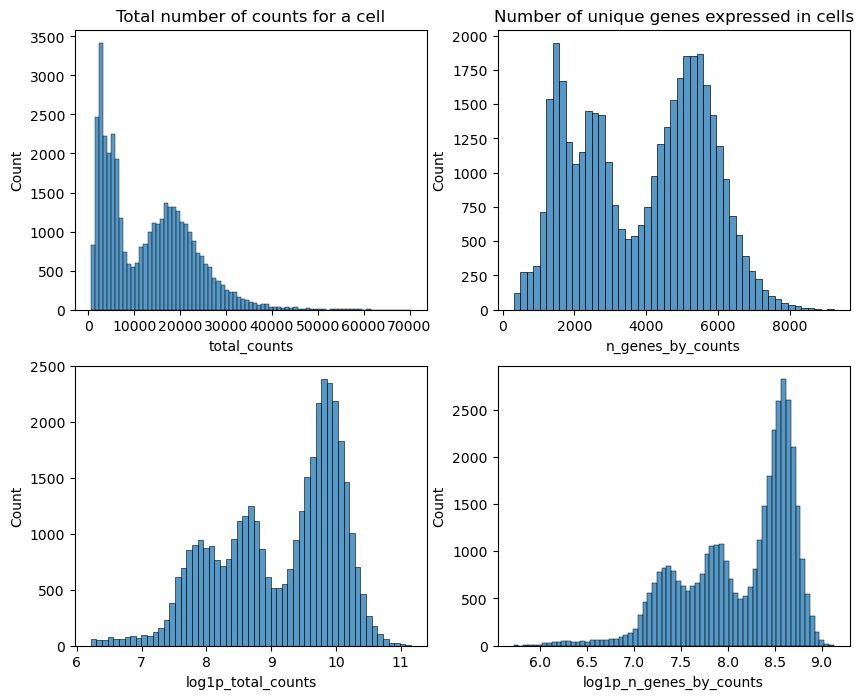

In [13]:
fig, axs = plt.subplots(2,2, figsize=(10,8))

sns.histplot(adata.obs["total_counts"], ax=axs[0,0])
axs[0,0].set_title("Total number of counts for a cell")

sns.histplot(adata.obs["n_genes_by_counts"], ax=axs[0,1])
axs[0,1].set_title("Number of unique genes expressed in cells")

sns.histplot(adata.obs["log1p_total_counts"], ax=axs[1,0])

sns.histplot(adata.obs["log1p_n_genes_by_counts"], ax=axs[1,1])

plt.show()

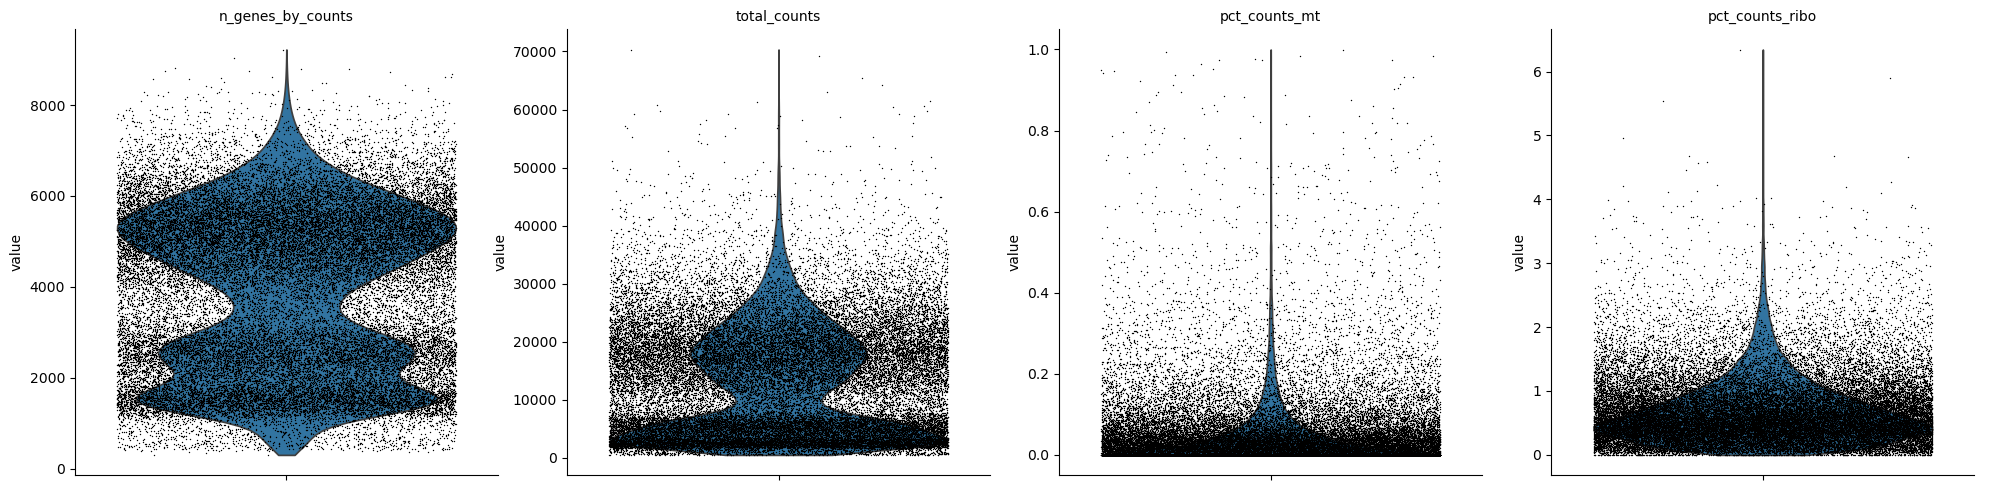

In [14]:
# scanpy, plotting, violin
adata.var_names_make_unique()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/p6/sybd66w15k9_sz65dtgk6hym0000gp/T/ipykernel_38689/3106792241.py:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  axes.text(np.log1p(3), 20000, "$\geq$3 genes per cell")


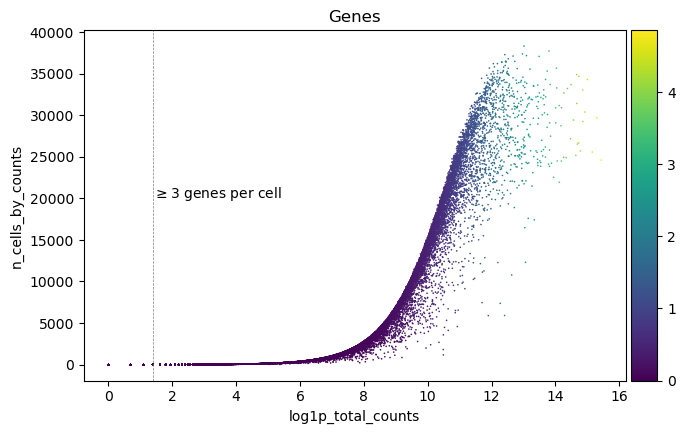

In [15]:
axes = sc.pl.scatter(adata, "log1p_total_counts", "n_cells_by_counts", color="log1p_mean_counts", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(np.log1p(3), c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.set_title("Genes")
axes.text(np.log1p(3), 20000, "$\geq$3 genes per cell")
plt.show()


<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/p6/sybd66w15k9_sz65dtgk6hym0000gp/T/ipykernel_38689/3505412505.py:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  axes.text(2000, 6000, "$\geq$2000 counts per cell")


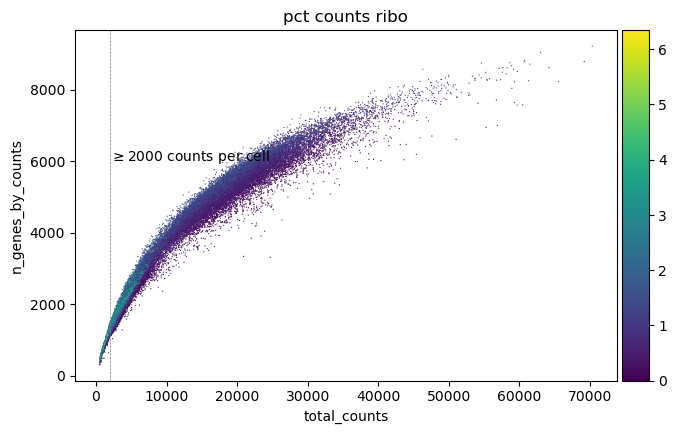

In [16]:
axes = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_ribo", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(2000, c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.text(2000, 6000, "$\geq$2000 counts per cell")
plt.show()



In [ ]:
# number of cells w/ total gene counts > 2000
cells_pass = sum(adata.obs["total_counts"]>2000)
print(f"{cells_pass}/{adata.n_obs} cells pass")

# number of genes w/ total cell counts > 3
genes_pass = sum(adata.var["total_counts"]>3)
print(f"{genes_pass}/{adata.n_vars} genes pass")

37301/39530 cells pass
19066/21899 genes pass


In [18]:
sc.pp.filter_cells(adata, min_counts=2000)
sc.pp.filter_genes(adata, min_cells=3)
adata

AnnData object with n_obs × n_vars = 37303 × 19277
    obs: 'ClusterKey', 'ClusterNm', 'derived_cell_libs', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

# Doublet Detection

In [19]:
sc.pp.scrublet(adata)
print(f"Number of predicted doublets: {sum(adata.obs["predicted_doublet"])}")

Number of predicted doublets: 819
